In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
cat = pd.read_pickle('../datos/procesados/cat_resultado_calidad.pkl')
num = pd.read_pickle('../datos/procesados/num_resultado_calidad.pkl')
train = pd.read_pickle('../datos/procesados/train_resultado_calidad.pkl')

## ANÁLISIS ESTADÍSTICO
### Categoricas
Fecuencia

In [4]:
def frecuencias_cat(df_cat):
    resultado = df_cat.apply(lambda x: x.value_counts(normalize = True)).T.stack()\
                .to_frame().reset_index()\
                .rename(columns={'level_0':'Variable','level_1':'Valor',0: "Frecuencia"})\
                .sort_values(by = ['Variable','Frecuencia'])
    return(resultado)

In [5]:
frecuencias_cat(cat)

,Variable,Valor,Frecuencia
16,calificacion_prestamo,G,0.002071
15,calificacion_prestamo,F,0.007335
14,calificacion_prestamo,E,0.030497
13,calificacion_prestamo,D,0.113774
12,calificacion_prestamo,C,0.199333
11,calificacion_prestamo,B,0.319074
10,calificacion_prestamo,A,0.327917
18,incumplimiento_historial,Y,0.178593
17,incumplimiento_historial,N,0.821407
6,intencion_prestamo,HOMEIMPROVEMENT,0.111844


Cardinalidad

In [6]:
cat.nunique()

propiedad_vivienda          4
intencion_prestamo          6
calificacion_prestamo       7
incumplimiento_historial    2
dtype: int64

### Contínuas

In [7]:
def estadisticos_cont(df_cont):
    #Calculamos describe
    estadisticos = df_cont.describe().T
    #Añadimos la mediana
    estadisticos['median'] = df_cont.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [8]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
edad,28495.0,27.723530,26.00,6.177199,20.00,23.00,26.00,30.00,84.00
ingreso,28495.0,66430.474574,56000.00,51513.742580,4000.00,39480.00,56000.00,80000.00,2039784.00
duracion_empleo,28495.0,4.781751,4.00,4.037958,0.00,2.00,4.00,7.00,41.00
monto_prestamo,28495.0,9657.366205,8000.00,6327.711290,500.00,5000.00,8000.00,12500.00,35000.00
tasa_interes,28495.0,11.045220,10.99,3.230786,5.42,7.90,10.99,13.48,23.22
estado_prestamo,28495.0,0.217126,0.00,0.412296,0.00,0.00,0.00,0.00,1.00
porcentaje_ingreso,28495.0,0.169517,0.15,0.106379,0.00,0.09,0.15,0.23,0.83
duracion_credito,28495.0,5.800316,4.00,4.040800,2.00,3.00,4.00,8.00,30.00


El ingreso es una variable que suele tener valores muy altos, por lo que vamos a calcular el límite para detectar outliers utilizando el método del IQR.

In [9]:
Q1 = num['ingreso'].quantile(0.25)
Q3 = num['ingreso'].quantile(0.75)
IQR = Q3 - Q1
limite = Q3 + 1.5 * IQR

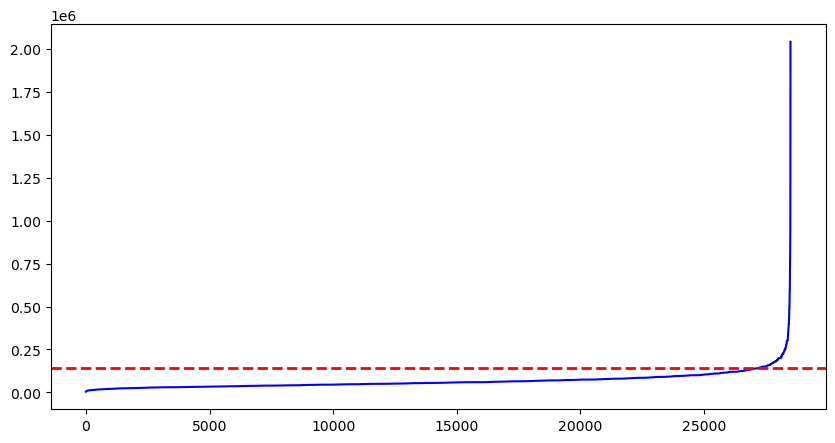

In [10]:
num.ingreso.sort_values().reset_index(drop=True).plot(kind='line', color='blue', figsize=(10, 5))
plt.axhline(y=limite, color='red', linestyle='--', linewidth=2, label='Línea de Referencia')
plt.show()

In [11]:
index = num[num['ingreso'] > limite].index
num = num.drop(index)
cat = cat.drop(index)
train = train.drop(index)

In [12]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
edad,27175.0,27.595584,26.00,6.117346,20.00,23.00,26.00,30.00,84.00
ingreso,27175.0,59206.487912,54050.00,27425.557104,4000.00,38400.00,54050.00,75000.00,140400.00
duracion_empleo,27175.0,4.703772,4.00,3.962906,0.00,2.00,4.00,7.00,41.00
monto_prestamo,27175.0,9358.374425,8000.00,6051.884643,500.00,5000.00,8000.00,12000.00,35000.00
tasa_interes,27175.0,11.030593,10.99,3.226091,5.42,7.90,10.99,13.48,23.22
estado_prestamo,27175.0,0.222815,0.00,0.416143,0.00,0.00,0.00,0.00,1.00
porcentaje_ingreso,27175.0,0.173710,0.15,0.106648,0.01,0.09,0.15,0.23,0.83
duracion_credito,27175.0,5.722760,4.00,3.991247,2.00,3.00,4.00,8.00,30.00


## Análisis gráfico

### Categóricas

In [13]:
def graficos_eda_categoricos(df_cat):
    
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(df_cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(df_cat):
        df_cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 10, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

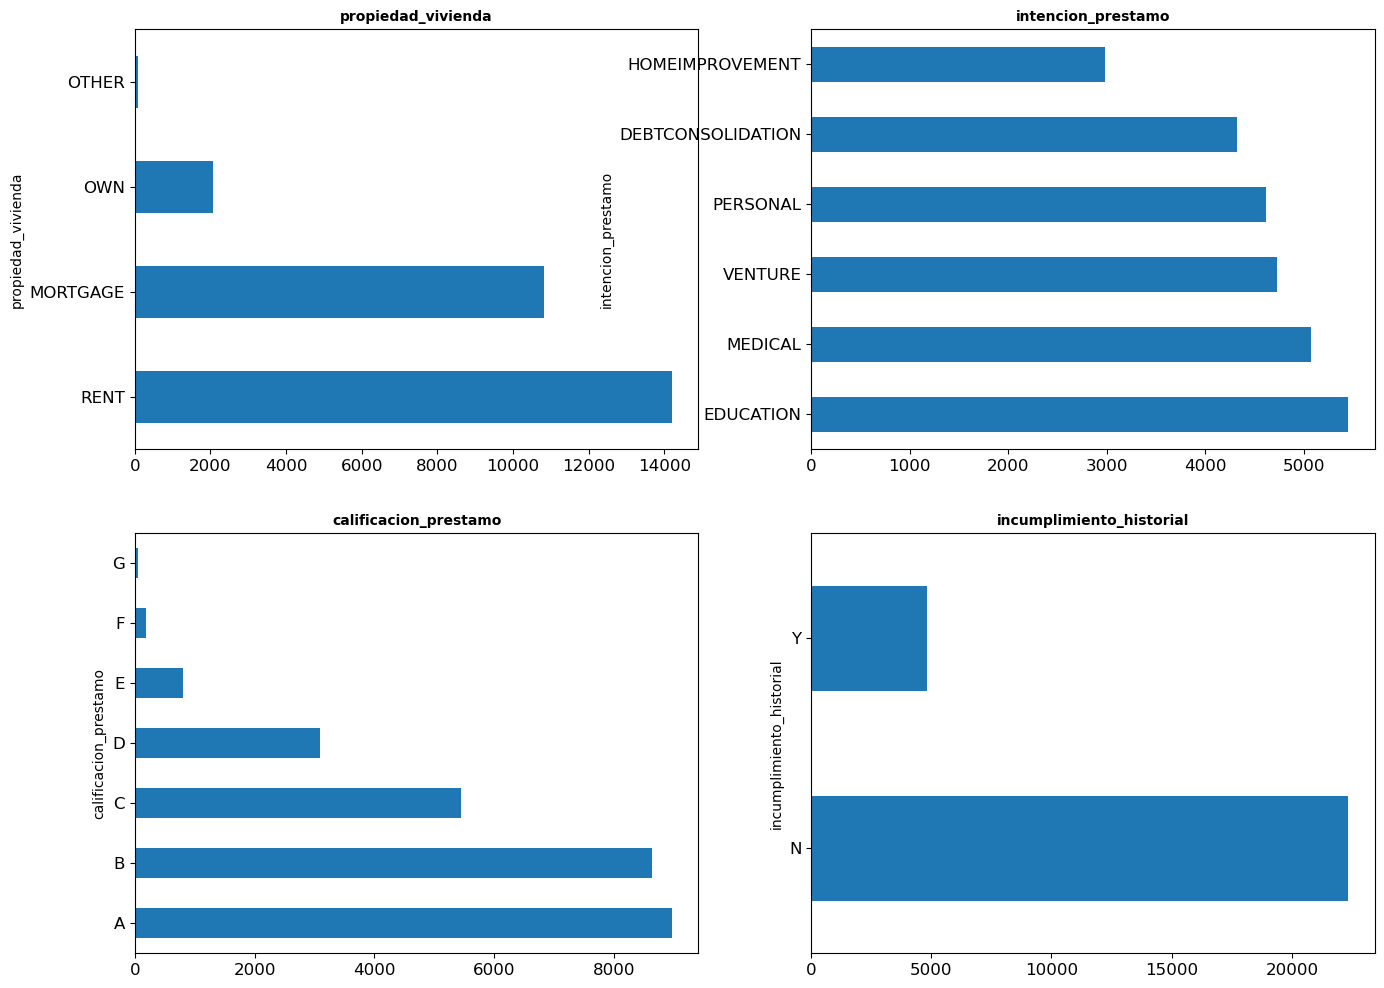

In [14]:
graficos_eda_categoricos(cat)

In [15]:
index = cat[cat['propiedad_vivienda'] == "OTHER"].index
num = num.drop(index)
cat = cat.drop(index)
train = train.drop(index)

### Continuas

In [16]:
def graficos_eda_continuas(df_cont):
    
    #Calculamos el número de fila que necesitamos
    from math import ceil
    filas = ceil(df_cont.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(df_cont):
        df_cont[variable].plot.density(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

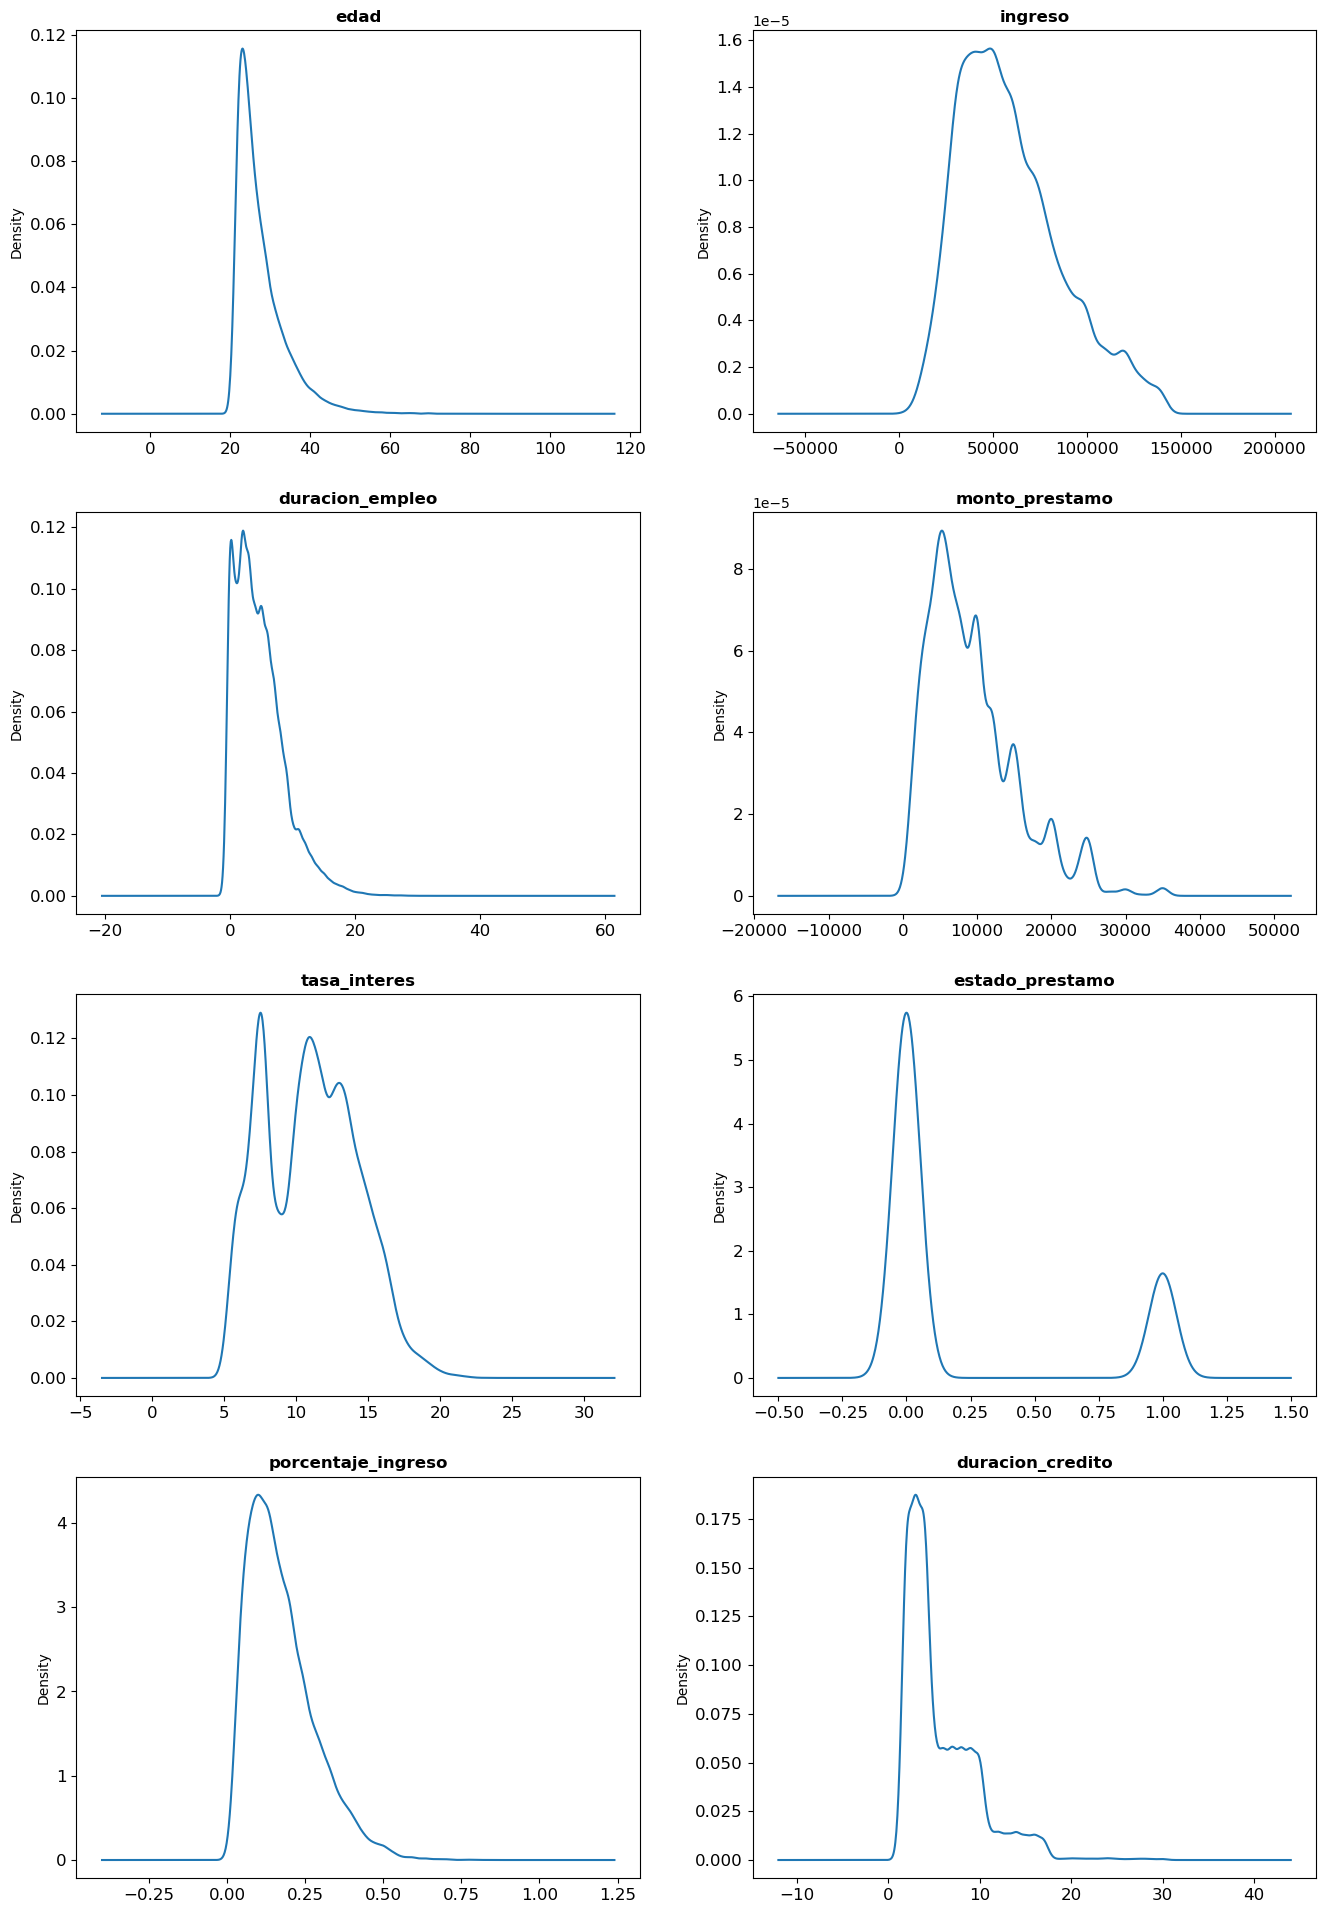

In [17]:
graficos_eda_continuas(num)

In [18]:
train.to_pickle("../datos/procesados/train_EDA.pkl")
cat.to_pickle("../datos/procesados/cat_EDA.pkl")
num.to_pickle("../datos/procesados/num_EDA.pkl")